# Пошуковий аналіз даних

<h2>Мета</h2>

Ознайомитись з методами перевірки статистичних гіпотез. Після завершення цієї лабораторної роботи ви зможете:

* Досліджувати дані за допомогою візуалізацій
* Робити описовий аналіз
* Групувати дані для аналізу
* Знаходити зв'язок між ознаками
* Перевіряти гіпотези про значущість коефіцієнта кореляції та про вигляд закону розподілу
* Робити дисперсійний аналіз



<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>


1. Скачати дані із файлу, який зберегли наприкінці попередньої роботи (з виправленими помилками та заповненими пропусками). Записати дані у dataframe. Дослідити ознаки з метою виявлення звязку між ними, побудувавши їх візуалізації. Візуально оцініть наявність та силу зв'язку між ознаками.
2. Порахувати кореляцію між всіма кількісними ознаками
3. Побудувати діаграми розсіювання для кількісних ознак та 'CO2 emission'. Які кількісні ознаки можуть бути предикторами кількості викидів СО2?
4. Побудувати діаграму розмаху для 'CO2 emission' по регіонам.
5. Виконати дисперсійний аналіз для кількості викидів СО2, згрупувати дані по регіонам


<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Дослідити ознаки з метою виявлення зв'язку між ними, побудувавши їх візуалізації</p>
</div>


Зчитую дані з файлу у датафрейм

In [2]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_PATH = 'data/clean_data.csv'

df = pd.read_csv(DATA_PATH, sep=';', encoding='cp1252')

df[['country_name', 'region']] =  df[['country_name', 'region']].astype('string')
df.dtypes


country_name          string[python]
region                string[python]
gdp_per_capita                 int64
population                     int64
co2_emission                 float64
area                         float64
population_density           float64
dtype: object

In [3]:
df.head(20)

,country_name,region,gdp_per_capita,population,co2_emission,area,population_density
0,Afghanistan,South Asia,5617787463,34656032,9809.225,652860.0,53.083405
1,Albania,Europe & Central Asia,412498239,2876101,5716.853,28750.0,100.038296
2,Algeria,Middle East & North Africa,3916881571,40606052,145400.217,2381740.0,17.048902
3,Andorra,Europe & Central Asia,3698862203,77281,462.042,470.0,164.427660
4,Angola,Sub-Saharan Africa,3308700233,28813463,34763.160,1246700.0,23.111786
5,Antigua and Barbuda,Latin America & Caribbean,1446217628,100963,531.715,440.0,229.461364
6,Argentina,Latin America & Caribbean,1244032098,43847430,204024.546,2780400.0,15.770188
7,Armenia,Europe & Central Asia,3614688357,2924816,5529.836,29740.0,98.346200
8,Aruba,Latin America & Caribbean,3675459700,104822,872.746,180.0,582.344444
9,Australia,East Asia & Pacific,4975531548,24127159,361261.839,7741220.0,3.116713


Будую діаграми

(0.0, 10819758.898183722)

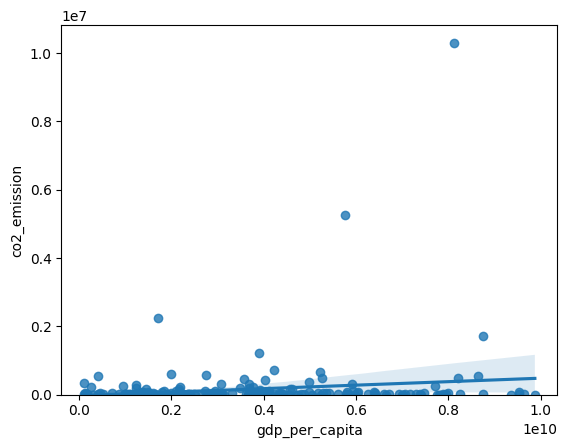

In [4]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання

headers = [
    'country_name',
    'region',
    'gdp_per_capita',
    'population',
    'co2_emission',
    'area',
]


sns.regplot(x='gdp_per_capita', y='co2_emission', data=df)
plt.ylim(0,)



Зі збільшенням ввп на душу населення викиди СО2 трохи зменшуються. Це вказує на слабку кореляцію між цими двома ознаками. Однак, є винятки, коли країни з високим ВВП мають відносно високі показники викидів CO2

(0.0, 1451427467.3843935)

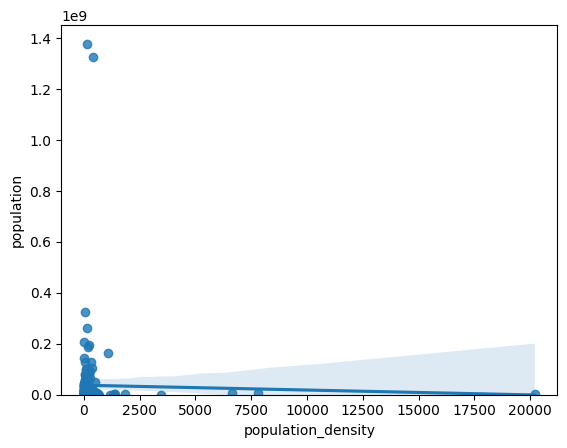

In [5]:
sns.regplot(x='population_density', y='population', data=df)
plt.ylim(0,)

Ця діаграма не показує кореляцію між цими двома показниками

(0.0, 12128379.195517158)

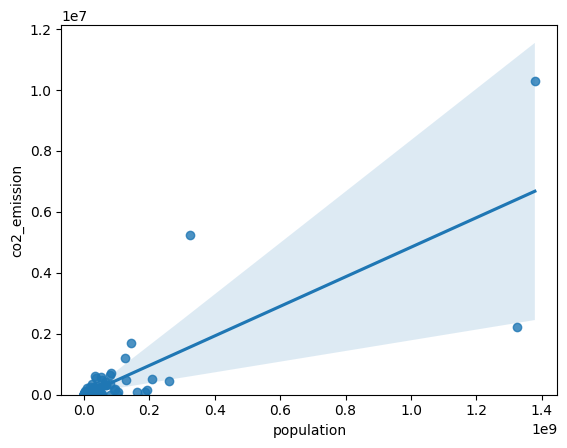

In [6]:
sns.regplot(x='population', y='co2_emission', data=df)
plt.ylim(0,)

Цей графік вказує на майже відсутність кореляції між цими двома ознаками. Однак, є винятки, коли країни з високою популяцією мають відносно високі показники викидів CO2

<a name="task2"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Порахувати кореляцію між всіма кількісними ознаками</p>
</div>


Рахую кореляцію між всіма кількісними ознаками

In [7]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
df.corr(numeric_only=True)

,gdp_per_capita,population,co2_emission,area,population_density
gdp_per_capita,1.000000,0.062268,0.143575,0.172900,0.123302
population,0.062268,1.000000,0.803804,0.451147,-0.021892
co2_emission,0.143575,0.803804,1.000000,0.587480,-0.022537
area,0.172900,0.451147,0.587480,1.000000,-0.063490
population_density,0.123302,-0.021892,-0.022537,-0.063490,1.000000


<a name="task3"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Побудувати діаграми розсіювання для кількісних ознак та 'CO2 emission'. Візуально оцінити наявність та силу зв'язку між цими ознаками.</p>
</div>


Будую діаграму розсіювання для кількісних ознак та 'CO2 emission'

(0.0, 12541891.94202421)

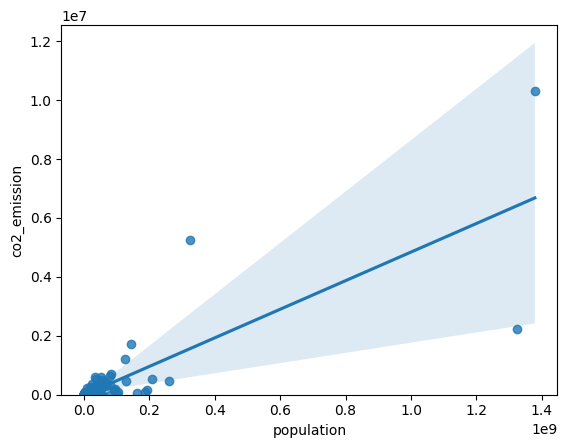

In [8]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
sns.regplot(x='population', y='co2_emission', data=df)
plt.ylim(0,)

(0.0, 10844260.077813366)

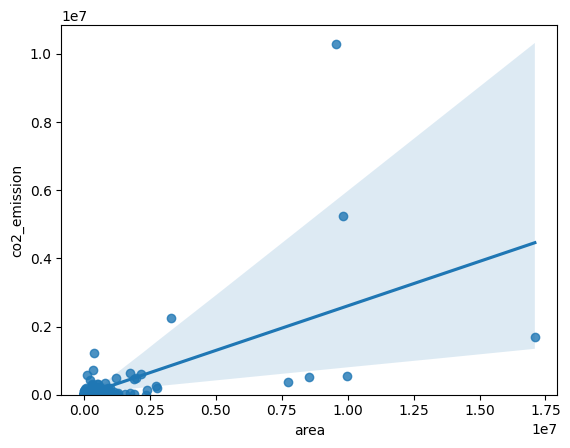

In [9]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
sns.regplot(x='area', y='co2_emission', data=df)
plt.ylim(0,)

Зі збільшенням площі викиди СО2 майже не змінюються. Це вказує на слабку кореляцію між цими двома ознаками. Однак, є винятки, коли країни з великою площею мають відносно високі показники викидів CO2

(0.0, 10858305.617231632)

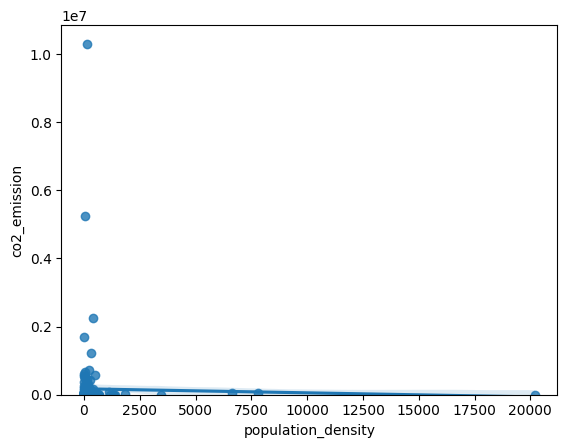

In [10]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
sns.regplot(x='population_density', y='co2_emission', data=df)
plt.ylim(0,)

Ця діаграма не показує кореляцію між цими двома показниками

<p>Які кількісні ознаки можуть бути предикторами кількості викидів СО2?</p>
<p>Обчислюю коефіцієнт кореляції Пірсона та P-value для всіх кількісних змінних та 'CO2 emission'</p>

In [11]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання

import scipy.stats as stats

quantitative_features = ['gdp_per_capita', 'population', 'area', 'population_density']

correlation_results = {}
for feature in quantitative_features:
    corr, p_value = stats.pearsonr(df[feature], df['co2_emission'])
    correlation_results[feature] = {'Pearson Correlation': corr, 'P-value': p_value}

correlation_df = pd.DataFrame.from_dict(correlation_results, orient='index')

print(correlation_df)


                    Pearson Correlation       P-value
gdp_per_capita                 0.143575  3.999822e-02
population                     0.803804  1.128895e-47
area                           0.587480  2.061861e-20
population_density            -0.022537  7.483995e-01


1. **`gdp_per_capita` (ВВП на душу населення)**  
   -  Слабка позитивна кореляція (**r = 0.1436**).  
   -  P-value < 0.05, кореляція статистично значуща.  
   -  Висновок: Більш розвинені країни мають трохи вищі викиди CO₂, але зв’язок слабкий.

2. **`population` (Населення)**  
   -  Сильна позитивна кореляція (**r = 0.8038**).  
   -  P-value ≈ 0, зв’язок дуже значущий.  
   -  Висновок: Чим більше населення, тим вищі викиди CO₂.

3. **`area` (Площа країни)**  
   -  Середня позитивна кореляція (**r = 0.5875**).  
   -  P-value ≈ 0, зв’язок значущий.  
   -  Висновок: Великі країни мають вищі викиди, можливо, через індустріалізацію.

4. **`population_density` (Густота населення)**  
   -  Майже нульова кореляція (**r = -0.0225**).  
   -  P-value > 0.05, зв’язок незначущий.  
   -  Висновок: Густонаселені країни можуть мати різні рівні викидів.

Кількісні ознаки, які можуть бути предикторами кількості викидів CO₂:

- population – найсильніший предиктор (r = 0.8038, P-value ≈ 0). Велике населення сприяє вищим викидам CO₂.

- area  – середній позитивний зв’язок (r = 0.5875, P-value ≈ 0). Великі країни часто мають більше промисловості та транспорту.

- gdp_per_capita – слабкий, але статистично значущий зв’язок (r = 0.1436, P-value = 0.03999). Економічний розвиток впливає на викиди, але не є ключовим фактором.

❌ population_density – не є предиктором (r = -0.0225, P-value = 0.7484), оскільки не має значущого впливу на викиди CO₂.

<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудувати діаграму розмаху для 'CO2 emission' по регіонам. </p>
</div>


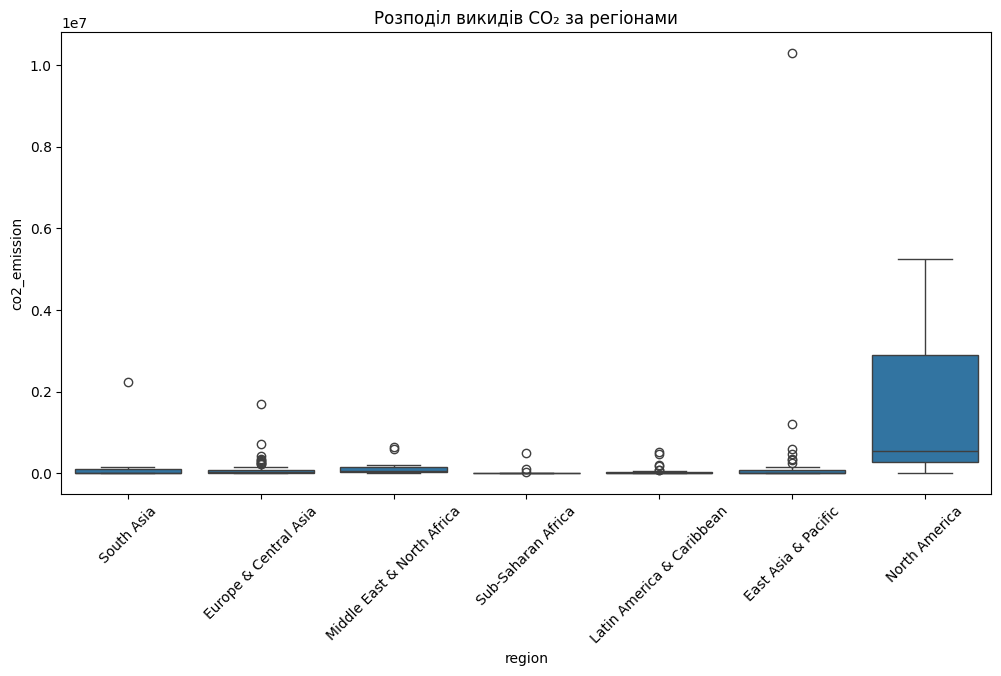

In [12]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання

plt.figure(figsize=(12, 6))
sns.boxplot(x="region", y="co2_emission", data=df)
plt.xticks(rotation=45)
plt.title("Розподіл викидів CO₂ за регіонами")
plt.show()

Ми бачимо що розподіл по регіонах сильно збігається, тому регіон не буде хорошим показником CO2, лише North America вирізняється

<a name="task5"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Виконати дисперсійний аналіз для кількості викидів СО2, згрупувати дані по регіонам</p>
</div>


Групую дані, щоб побачити чи впливає 'Region' на 'CO2 emission'.

In [13]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
co2_emission_by_region = df[["region", "co2_emission"]].groupby("region")
co2_emission_by_region.head()


,region,co2_emission
0,South Asia,9.809225e+03
1,Europe & Central Asia,5.716853e+03
2,Middle East & North Africa,1.454002e+05
3,Europe & Central Asia,4.620420e+02
4,Sub-Saharan Africa,3.476316e+04
5,Latin America & Caribbean,5.317150e+02
6,Latin America & Caribbean,2.040245e+05
7,Europe & Central Asia,5.529836e+03
8,Latin America & Caribbean,8.727460e+02
9,East Asia & Pacific,3.612618e+05


Перевіряю розподіл даних в групах, щоб обрати вид дисперсійного аналізу.

Візуальний аналіз

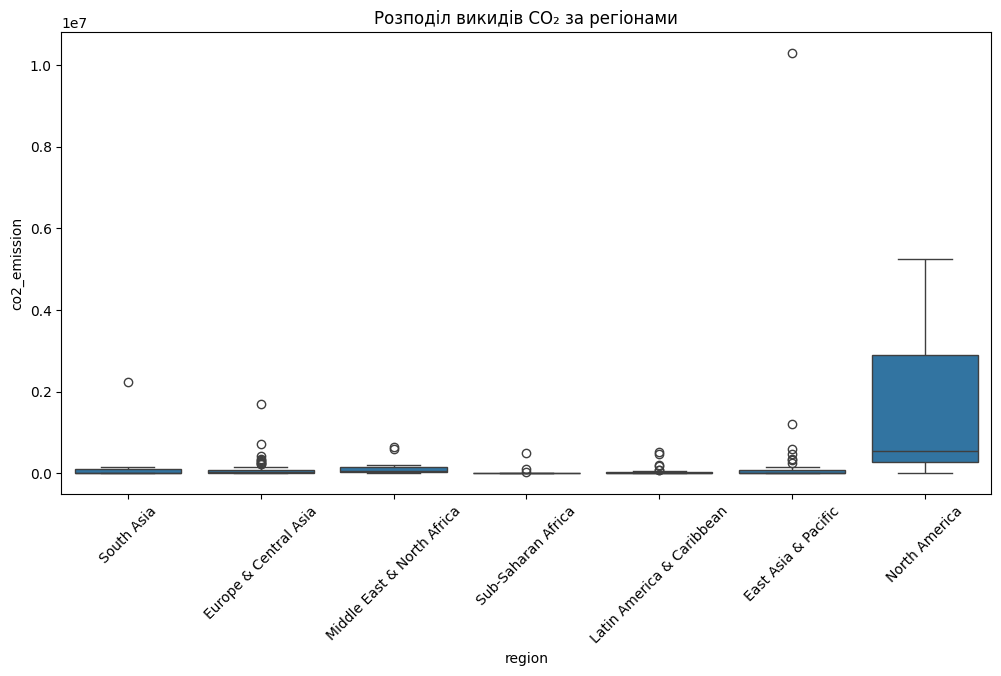

In [14]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
plt.figure(figsize=(12, 6))
sns.boxplot(x="region", y="co2_emission", data=df)
plt.xticks(rotation=45)
plt.title("Розподіл викидів CO₂ за регіонами")
plt.show()


Перевірка нормальності 

In [15]:
from scipy.stats import shapiro

for region, group in co2_emission_by_region:
    stat, p = shapiro(group["co2_emission"])
    print(f"{region}: p-value = {p}")

East Asia & Pacific: p-value = 3.9250569772172254e-12
Europe & Central Asia: p-value = 8.532206356599176e-13
Latin America & Caribbean: p-value = 8.0228733839871e-11
Middle East & North Africa: p-value = 1.0810064373215058e-05
North America: p-value = 0.17751878061974782
South Asia: p-value = 4.837926661431852e-06
Sub-Saharan Africa: p-value = 1.3856710673018501e-14


Перевірка гомогенності дисперсії

In [16]:
from scipy.stats import levene

stat, p = levene(*[group["co2_emission"] for _, group in co2_emission_by_region])
print(f"Тест Левене: p-value = {p}")


Тест Левене: p-value = 0.006575550992920958


Аналіз результатів тестів
Перевірка нормальності (Тест Шапіро-Уїлка):

Для більшості регіонів p-value < 0.05, що свідчить про нормальність, що не виконується.
Лише для North America p-value > 0.05, що означає, що лише ця група може мати нормальний розподіл.
Перевірка гомогенності дисперсій (Тест Левене):

p-value = 0.0066 (< 0.05) → дисперсії неоднорідні.
Це означає, що класичний ANOVA не можна використовувати, оскільки порушується припущення про рівність дисперсій.
Висновок:
Оскільки:

Нормальність даних не виконується у більшості груп.
Гомогенність дисперсій не виконується.
Маємо застосувати непараметричний тест Краскела-Уоліса

Для отримання F-test score та P-value скористаюсь функцією <<code>kruskal</code> з модуля "stats" для непараметричного дисперсійного аналізу Краскела-Уоліса.

In [17]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
from scipy.stats import kruskal

stat, p_val = kruskal(*[group["co2_emission"] for _, group in co2_emission_by_region])
print(f"F-статистика: {stat}")
print(f"Тест Краскела-Уоліса: p-value = {p_val}")



F-статистика: 39.36585270526004
Тест Краскела-Уоліса: p-value = 6.067666583117367e-07


Результат із F-статистикою 39.37 та P-value 6.07e-07 показує, що існує статистично значуща різниця між досліджуваними групами. Але чи означає це, що досліджувані групи значуще відрізняються між собою?

Розглянемо їх окремо.

In [18]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання

region_list = co2_emission_by_region.groups.keys()

for region in region_list:
    print(f"{region}:")
    
    for region2 in region_list:
        if region == region2:
            continue
        
        stat, p_val = kruskal(
            co2_emission_by_region.get_group(region)["co2_emission"],
            co2_emission_by_region.get_group(region2)["co2_emission"]
        )
        
        print(f"p-value для регіонів {region} та {region2}: {p_val}")
    

East Asia & Pacific:
p-value для регіонів East Asia & Pacific та Europe & Central Asia: 0.04636197871881841
p-value для регіонів East Asia & Pacific та Latin America & Caribbean: 0.9735342225866741
p-value для регіонів East Asia & Pacific та Middle East & North Africa: 0.01638310067292146
p-value для регіонів East Asia & Pacific та North America: 0.18174686425631176
p-value для регіонів East Asia & Pacific та South Asia: 0.3365857568465174
p-value для регіонів East Asia & Pacific та Sub-Saharan Africa: 0.4075100853429865
Europe & Central Asia:
p-value для регіонів Europe & Central Asia та East Asia & Pacific: 0.04636197871881841
p-value для регіонів Europe & Central Asia та Latin America & Caribbean: 0.0009992329177339616
p-value для регіонів Europe & Central Asia та Middle East & North Africa: 0.16977763338246388
p-value для регіонів Europe & Central Asia та North America: 0.2997127812474501
p-value для регіонів Europe & Central Asia та South Asia: 0.7164461600894922
p-value для регіо

## Висновки на основі тесту Краскела-Уоліса

### 1. Регіони зі значними відмінностями в середніх значеннях викидів CO2:
- **East Asia & Pacific** і **Europe & Central Asia**: p-value = 0.046. Це свідчить про статистично значущу різницю між середніми значеннями викидів CO2 в цих двох регіонах.
- **Europe & Central Asia** і **Latin America & Caribbean**: p-value = 0.000999. Різниця є статистично значущою.
- **Latin America & Caribbean** і **Middle East & North Africa**: p-value = 0.000245. Це вказує на значущу різницю між цими двома регіонами.
- **Sub-Saharan Africa** та **Europe & Central Asia**: p-value = 6.94e-08. Це показує, що є значущі відмінності між цими двома регіонами за викидами CO2.

### 2. Регіони, де відмінностей у середніх значеннях викидів CO2 немає:
- **East Asia & Pacific** і **Latin America & Caribbean**: p-value = 0.973. Різниця не є статистично значущою.
- **North America** та **South Asia**: p-value = 0.540. Відмінності між цими регіонами незначущі.
- **Middle East & North Africa** і **North America**: p-value = 0.465. Відмінності також не є статистично значущими.

<a name="task6"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Дайте відповіді на питання</p>
</div>


1. По результатам дисперсійного аналізу для кількості викидів СО2 по регіонам, вкажіть пару регіонів, що відрізняються найсильніше.
2. Створіть якісну ознаку 'Rich country', згрупувавши дані 'GDP per capita' в кілька категорій (багаті-бідні країни, 3-5 категорій). Побудуйте діаграму розмаху для 'CO2 emission' по категоріям 'Rich country'. Візуально оцініть наявність зв'язку між цими ознаками.
3. Виконайте дисперсійний аналіз для 'CO2 emission', згрупувавши дані по категоріям 'Rich country'.

<details><summary>Натисніть тут, щоб побачити підказку</summary>

Групування кількісної змінної в категорії було в попередній лабораторній роботі. Використайте функцію "cut"
</details>

In [19]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
regions_result = [float('-inf'), None, None, None]  # [F-stat, region1, region2, p-value]
group_names = list(co2_emission_by_region.groups.keys())

for i1, (region1, group1) in enumerate(co2_emission_by_region):
    for i2, (region2, group2) in enumerate(co2_emission_by_region):
        if i1 >= i2:
            continue
        f, p = stats.f_oneway(group1['co2_emission'], group2['co2_emission'])
        if f > regions_result[0] and p < 0.05:
            regions_result = [f, region1, region2, p]

# Регіони, що відрізняються найсильніше
r1 = regions_result[1]
r2 = regions_result[2]
f = regions_result[0]
p = regions_result[3]
print(f'Пара регіонів, що відрізняються найсильніше: {r1} та {r2}\nF={f} P={p}')

Пара регіонів, що відрізняються найсильніше: North America та Sub-Saharan Africa
F=29.889184991922967 P=1.5319132629213808e-06


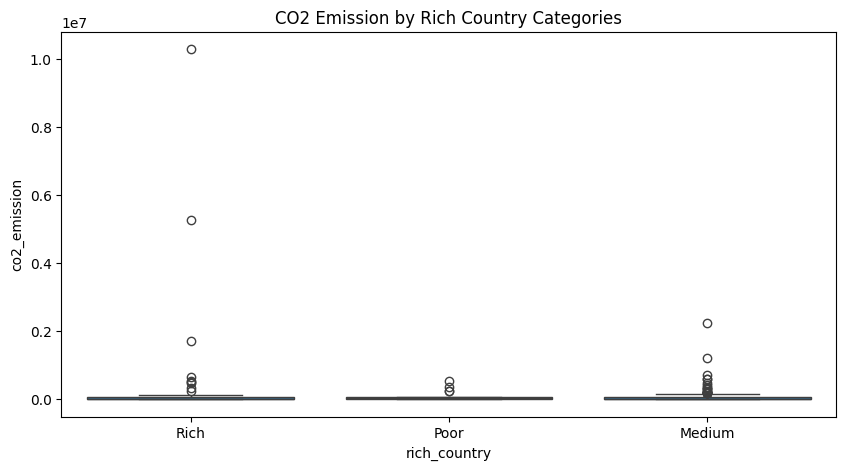

Кількість викидів вуглекислого газу не має лінійного зв'язку з тим, наскільки багата країна


In [20]:
def categorize_gdp(gdp):
    if gdp < 1_000_000_000:
        return 'Poor'
    if gdp < 5_000_000_000:
        return 'Medium'
    return 'Rich'

df['rich_country'] = df['gdp_per_capita'].apply(categorize_gdp)

# Діаграма розмаху для 'CO2 emission' по категоріям 'Rich country'
plt.figure(figsize=(10, 5))
sns.boxplot(x='rich_country', y='co2_emission', data=df)
plt.title('CO2 Emission by Rich Country Categories')
plt.show()

print("Кількість викидів вуглекислого газу не має лінійного зв'язку з тим, наскільки багата країна")

In [21]:

grouped_df = df[['rich_country', 'co2_emission']].groupby(['rich_country'])
group_names = grouped_df['rich_country'].unique()

groups = [grouped_df.get_group((group[0],))['co2_emission'] for group in group_names]

f_val, p_val = stats.f_oneway(*groups)
print("ANOVA results: F =", f_val, ", P =", p_val)


for i, group in enumerate(groups):
    print(f'{group_names.iloc[i][0]}:\n' + f'{stats.shapiro(group)}')


print(stats.kruskal(*groups))

ANOVA results: F = 2.50678405901519 , P = 0.08406368117095847
Medium:
ShapiroResult(statistic=np.float64(0.36180357045389644), pvalue=np.float64(1.3678834572539401e-21))
Poor:
ShapiroResult(statistic=np.float64(0.6596769025781342), pvalue=np.float64(4.18209289184713e-05))
Rich:
ShapiroResult(statistic=np.float64(0.2566824101565216), pvalue=np.float64(3.5170662028047138e-15))
KruskalResult(statistic=np.float64(2.00671325153792), pvalue=np.float64(0.36664667767964293))


<h2>Виконав студент групи ІП-33 <br> Соколов Олександр</h2>